# Brain Tumor Segmentation using U-Net

## Setup Environment and Mount Google Drive

In [1]:
import sys
import os

# Check if running on Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ Running on Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Running on Local Environment")

# Mount Google Drive on Colab
if IN_COLAB:
    drive.mount('/content/drive')
    print("✓ Google Drive mounted successfully")

# Check GPU availability
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")

✓ Running on Google Colab
Mounted at /content/drive
✓ Google Drive mounted successfully
✓ Using device: cuda
  GPU: Tesla T4
  CUDA Version: 12.8


## Import Required Libraries

In [2]:
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Metrics
from sklearn.metrics import jaccard_score

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Configure Paths for Colab and Local Environments

In [3]:
# Configure paths based on environment
if IN_COLAB:
    BASE_PATH = "/content/drive/MyDrive/computer vision course/projects/Brain Tumor Segmentation via U-Net"
    DATASET_PATH = os.path.join(BASE_PATH, "Dataset")
    COLAB_OUTPUT_PATH = "/content/outputs"
    os.makedirs(COLAB_OUTPUT_PATH, exist_ok=True)
    print(f"✓ Colab mode - Dataset path: {DATASET_PATH}")
else:
    # Local path for VS Code
    DATASET_PATH = r"E:\courses\AI\9- Computer vision\3- Projects\Brain Tumor Segmentation via U-Net\Dataset"
    COLAB_OUTPUT_PATH = None
    print(f"✓ Local mode - Dataset path: {DATASET_PATH}")

# Verify dataset exists
train_path = os.path.join(DATASET_PATH, "train")
valid_path = os.path.join(DATASET_PATH, "valid")
test_path = os.path.join(DATASET_PATH, "test")

if os.path.exists(train_path) and os.path.exists(valid_path) and os.path.exists(test_path):
    print("✓ Dataset found!")
    print(f"  - Train: {train_path}")
    print(f"  - Valid: {valid_path}")
    print(f"  - Test: {test_path}")
else:
    print("⚠ Dataset path not found. Please verify the path is correct.")

# Configuration parameters
CONFIG = {
    'device': device,
    'batch_size': 16,
    'epochs': 50,
    'learning_rate': 0.001,
    'img_size': (256, 256),
    'patience': 5,  # for early stopping
}

✓ Colab mode - Dataset path: /content/drive/MyDrive/computer vision course/projects/Brain Tumor Segmentation via U-Net/Dataset
✓ Dataset found!
  - Train: /content/drive/MyDrive/computer vision course/projects/Brain Tumor Segmentation via U-Net/Dataset/train
  - Valid: /content/drive/MyDrive/computer vision course/projects/Brain Tumor Segmentation via U-Net/Dataset/valid
  - Test: /content/drive/MyDrive/computer vision course/projects/Brain Tumor Segmentation via U-Net/Dataset/test


## Load and Explore Dataset

In [4]:
def create_mask_from_annotation(annotation, img_height, img_width):
    """Create binary mask from polygon annotation"""
    mask = np.zeros((img_height, img_width), dtype=np.uint8)

    if 'segmentation' in annotation and len(annotation['segmentation']) > 0:
        segments = annotation['segmentation']
        for segment in segments:
            if len(segment) >= 6:  # At least 3 points (6 coordinates)
                polygon = np.array(segment, dtype=np.int32).reshape(-1, 2)
                cv2.fillPoly(mask, [polygon], 1)

    return mask

def load_coco_data(json_path, dataset_dir, min_tumor_pixels=100):
    """Load COCO format annotations and create image-mask pairs.
    ✅ FIXED: Now filters out images without meaningful tumors (empty masks)"""
    with open(json_path, 'r', encoding='utf-8-sig') as f:
        coco_data = json.load(f)

    image_data = {}
    for img_info in coco_data['images']:
        img_id = img_info['id']
        image_data[img_id] = {
            'file_name': img_info['file_name'],
            'height': img_info['height'],
            'width': img_info['width'],
            'path': os.path.join(dataset_dir, img_info['file_name'])
        }

    # Create mask array for each image
    masks_dict = {}
    for img_id in image_data:
        masks_dict[img_id] = None

    for annotation in coco_data['annotations']:
        img_id = annotation['image_id']
        if img_id in image_data:
            img_h = image_data[img_id]['height']
            img_w = image_data[img_id]['width']
            mask = create_mask_from_annotation(annotation, img_h, img_w)

            if masks_dict[img_id] is None:
                masks_dict[img_id] = mask
            else:
                masks_dict[img_id] = np.maximum(masks_dict[img_id], mask)

    # Build dataset with filtering
    dataset_list = []
    skipped_count = 0
    for img_id, img_info in image_data.items():
        mask = masks_dict[img_id]
        if mask is None:
            mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

        # ✅ FILTER: Skip images without meaningful tumors (< min_tumor_pixels)
        tumor_pixels = np.sum(mask)
        if tumor_pixels < min_tumor_pixels:
            skipped_count += 1
            continue

        dataset_list.append({
            'image_path': img_info['path'],
            'mask': mask,
            'height': img_info['height'],
            'width': img_info['width']
        })

    print(f"  ✓ Loaded {len(dataset_list)} images, skipped {skipped_count} without tumors")
    return dataset_list

# Load datasets with tumor filtering
print("Loading COCO annotations with tumor filtering...")
train_data = load_coco_data(
    os.path.join(train_path, '_annotations.coco.json'),
    train_path,
    min_tumor_pixels=100
)
valid_data = load_coco_data(
    os.path.join(valid_path, '_annotations.coco.json'),
    valid_path,
    min_tumor_pixels=100
)
test_data = load_coco_data(
    os.path.join(test_path, '_annotations.coco.json'),
    test_path,
    min_tumor_pixels=100
)

print(f"✓ Train samples: {len(train_data)}")
print(f"✓ Validation samples: {len(valid_data)}")
print(f"✓ Test samples: {len(test_data)}")

Loading COCO annotations with tumor filtering...
  ✓ Loaded 1501 images, skipped 1 without tumors
  ✓ Loaded 429 images, skipped 0 without tumors
  ✓ Loaded 215 images, skipped 0 without tumors
✓ Train samples: 1501
✓ Validation samples: 429
✓ Test samples: 215


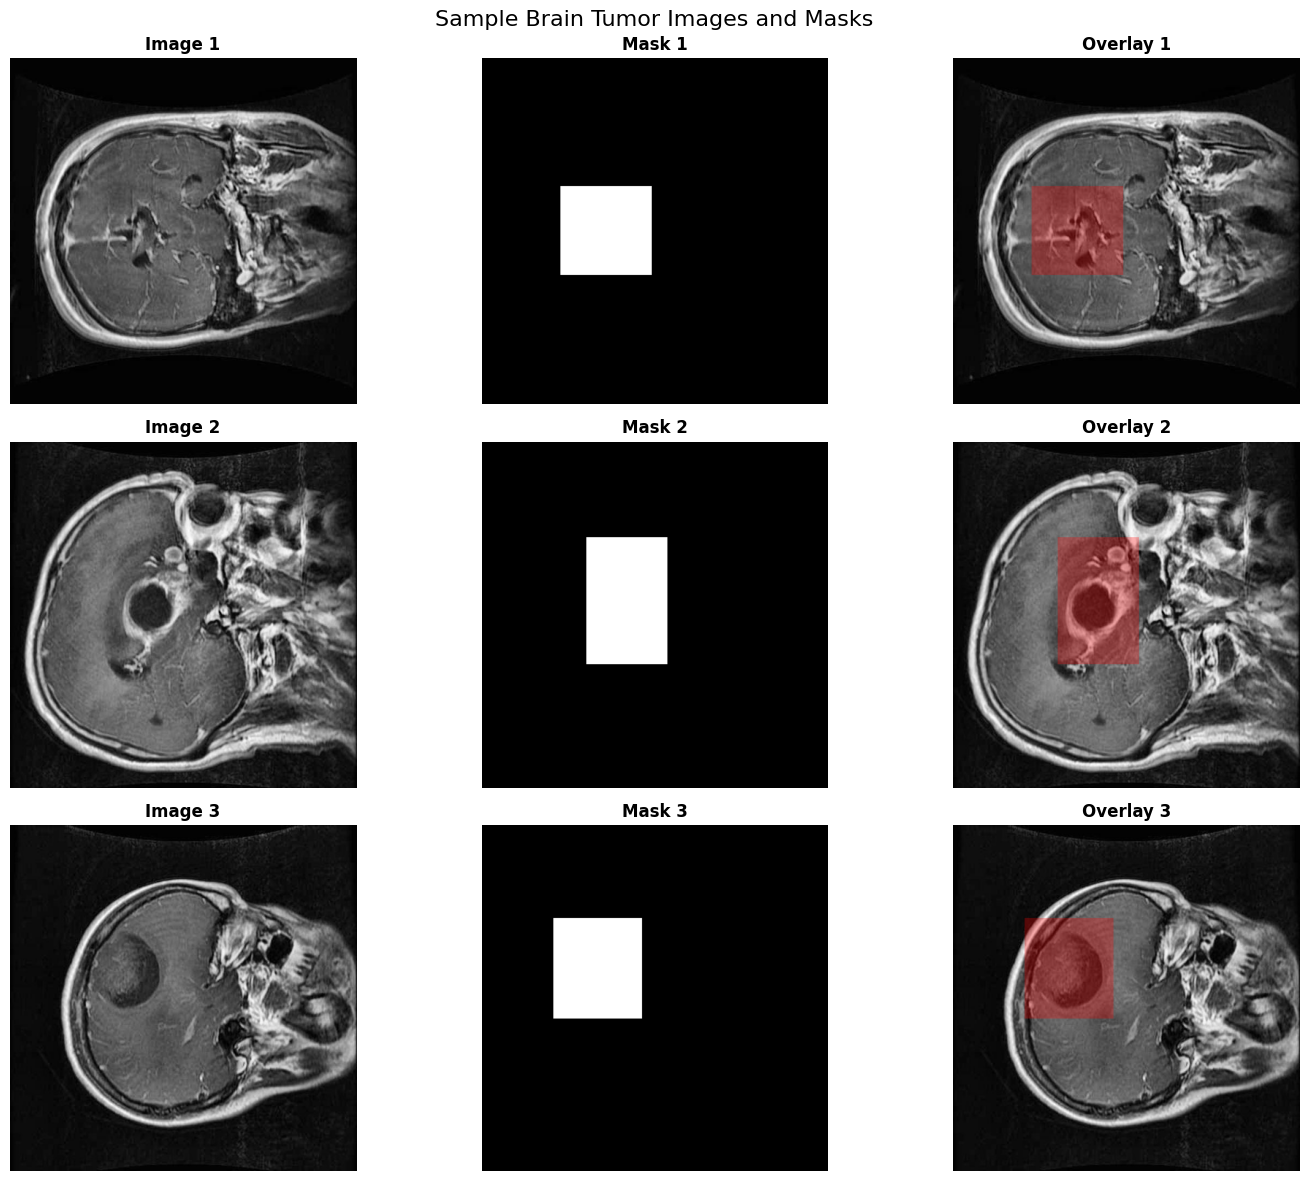


📊 Dataset Statistics:
  - Sample image size: 640x640
  - Total training samples: 1501
  - Total validation samples: 429
  - Total test samples: 215


In [5]:
# Visualize sample data
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Sample Brain Tumor Images and Masks', fontsize=16)

for idx in range(min(3, len(train_data))):
    # Load original image
    img = cv2.imread(train_data[idx]['image_path'])
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = np.zeros((train_data[idx]['height'], train_data[idx]['width'], 3), dtype=np.uint8)

    mask = train_data[idx]['mask']

    # Row for this sample
    row = idx

    # Original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Image {idx+1}', fontweight='bold')
    axes[row, 0].axis('off')

    # Mask
    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title(f'Mask {idx+1}', fontweight='bold')
    axes[row, 1].axis('off')

    # Overlay
    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]
    blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)
    axes[row, 2].imshow(blended)
    axes[row, 2].set_title(f'Overlay {idx+1}', fontweight='bold')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n📊 Dataset Statistics:")
print(f"  - Sample image size: {train_data[0]['height']}x{train_data[0]['width']}")
print(f"  - Total training samples: {len(train_data)}")
print(f"  - Total validation samples: {len(valid_data)}")
print(f"  - Total test samples: {len(test_data)}")

## Preprocess Images and Masks

In [6]:
class BrainTumorDataset(Dataset):
    """PyTorch Dataset for Brain Tumor Segmentation"""
    def __init__(self, data_list, img_size=(256, 256), augment=False):
        self.data_list = data_list
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # Load image
        img_path = self.data_list[idx]['image_path']
        image = cv2.imread(img_path)

        if image is None:
            # Handle missing images
            image = np.zeros((*self.img_size, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = self.data_list[idx]['mask']

        # Resize
        image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        # Data augmentation
        if self.augment:
            if np.random.rand() > 0.5:
                image = np.fliplr(image)
                mask = np.fliplr(mask)
            if np.random.rand() > 0.5:
                image = np.flipud(image)
                mask = np.flipud(mask)

        # Normalize image
        image = image.astype(np.float32) / 255.0
        # ✅ FIXED: Don't divide mask by 255 (cv2.fillPoly already returns 0 or 1)
        mask = mask.astype(np.float32)

        # Convert to tensors
        image = torch.from_numpy(image).permute(2, 0, 1)  # HWC -> CHW
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dimension

        return image, mask

# Create datasets
print("Creating PyTorch datasets...")
train_dataset = BrainTumorDataset(
    train_data,
    img_size=CONFIG['img_size'],
    augment=True
)
valid_dataset = BrainTumorDataset(
    valid_data,
    img_size=CONFIG['img_size'],
    augment=False
)
test_dataset = BrainTumorDataset(
    test_data,
    img_size=CONFIG['img_size'],
    augment=False
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2 if IN_COLAB else 0
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2 if IN_COLAB else 0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2 if IN_COLAB else 0
)

print(f"✓ Train loader: {len(train_loader)} batches of {CONFIG['batch_size']}")
print(f"✓ Valid loader: {len(valid_loader)} batches of {CONFIG['batch_size']}")
print(f"✓ Test loader: {len(test_loader)} batches of {CONFIG['batch_size']}")

Creating PyTorch datasets...
✓ Train loader: 94 batches of 16
✓ Valid loader: 27 batches of 16
✓ Test loader: 14 batches of 16


## Build U-Net Model Architecture

In [7]:
# ✅ FIXED: Import segmentation_models_pytorch for pre-trained U-Net
try:
    import segmentation_models_pytorch as smp
    print("✓ segmentation_models_pytorch imported successfully")
except ImportError:
    print("Installing segmentation_models_pytorch...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "segmentation_models_pytorch"])
    import segmentation_models_pytorch as smp

# ✅ Use Pre-trained U-Net with ResNet34 encoder (much better than custom U-Net)
print("\n✅ Building Pre-trained U-Net with ResNet34 encoder...")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",  # Pre-trained on ImageNet
    in_channels=3,
    classes=1,  # Binary segmentation (tumor vs non-tumor)
    decoder_use_batchnorm=True,
    decoder_attention_type=None
).to(CONFIG['device'])

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Pre-trained U-Net created successfully")
print(f"  - Encoder: ResNet34 (pre-trained on ImageNet)")
print(f"  - Total parameters: {total_params:,}")
print(f"  - Trainable parameters: {trainable_params:,}")

Installing segmentation_models_pytorch...

✅ Building Pre-trained U-Net with ResNet34 encoder...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✓ Pre-trained U-Net created successfully
  - Encoder: ResNet34 (pre-trained on ImageNet)
  - Total parameters: 24,436,369
  - Trainable parameters: 24,436,369


## Compile and Train Model with GPU

In [9]:
def dice_coefficient(pred, target, smooth=1e-6):
    """Calculate Dice coefficient - predicts are logits from model"""
    pred_sigmoid = torch.sigmoid(pred)
    pred_flat = pred_sigmoid.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    dice = (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
    return dice

def iou_coefficient(pred, target, smooth=1e-6):
    """Calculate Intersection over Union"""
    pred_sigmoid = torch.sigmoid(pred)
    pred_binary = (pred_sigmoid > 0.5).float().view(-1)
    target_flat = target.view(-1)
    intersection = (pred_binary * target_flat).sum()
    union = pred_binary.sum() + target_flat.sum() - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

# ✅ FIXED: Use Dice Loss which is superior for medical image segmentation
def dice_loss(pred, target, smooth=1.0):
    """Dice Loss - better for imbalanced segmentation tasks"""
    pred_sigmoid = torch.sigmoid(pred)
    intersection = (pred_sigmoid * target).sum()
    union = pred_sigmoid.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1 - dice

# Setup optimizer with the pre-trained model
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# ✅ FIXED: Add Learning Rate Scheduler for better convergence
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Training history
history = {
    'train_loss': [],
    'valid_loss': [],
    'train_dice': [],
    'valid_dice': [],
    'train_iou' : [],
    'valid_iou' : []
}

def train_epoch(model, train_loader, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    total_dice = 0
    total_iou = 0

    for batch_idx, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)  # outputs are logits (no sigmoid yet)
        loss = dice_loss(outputs, masks)  # ✅ Use Dice Loss, not BCE

        # Backward pass
        loss.backward()
        optimizer.step()

        # Metrics
        with torch.no_grad():
            dice = dice_coefficient(outputs, masks).item()
            iou = iou_coefficient(outputs, masks).item()

        total_loss += loss.item()
        total_dice += dice
        total_iou += iou

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    avg_dice = total_dice / len(train_loader)
    avg_iou = total_iou / len(train_loader)

    return avg_loss, avg_dice, avg_iou

def evaluate(model, val_loader, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)  # outputs are logits
            loss = dice_loss(outputs, masks)  # ✅ Use Dice Loss

            dice = dice_coefficient(outputs, masks).item()
            iou = iou_coefficient(outputs, masks).item()

            total_loss += loss.item()
            total_dice += dice
            total_iou += iou

    avg_loss = total_loss / len(val_loader)
    avg_dice = total_dice / len(val_loader)
    avg_iou = total_iou / len(val_loader)

    return avg_loss, avg_dice, avg_iou

# Training setup
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n{'-'*70}")
print(f"✅ Training Pre-trained U-Net with Dice Loss on {CONFIG['device']}")
print(f"{'-'*70}\n")

# Training loop
for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    print("-" * 50)

    # Train
    train_loss, train_dice, train_iou = train_epoch(
        model, train_loader, optimizer, CONFIG['device']
    )

    # Validate
    val_loss, val_dice, val_iou = evaluate(
        model, valid_loader, CONFIG['device']
    )

    # Store history
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['valid_dice'].append(val_dice)
    history['train_iou'].append(train_iou)
    history['valid_iou'].append(val_iou)

    print(f"Train - Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
    print(f"Valid - Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")

    # ✅ FIXED: Learning Rate Scheduling
    scheduler.step(val_loss)

    # Early stopping & best model tracking
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print("✓ Best model updated!")
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{CONFIG['patience']}")

        if patience_counter >= CONFIG['patience']:
            print(f"\n✓ Early stopping triggered at epoch {epoch+1}")
            break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("✓ Best model loaded")

print(f"\n✅ Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")


✅ Training Pre-trained U-Net with Dice Loss on cuda


Epoch 1/50
--------------------------------------------------
  Batch 10/94 | Loss: 0.8309
  Batch 20/94 | Loss: 0.8134
  Batch 30/94 | Loss: 0.7586
  Batch 40/94 | Loss: 0.7508
  Batch 50/94 | Loss: 0.7587
  Batch 60/94 | Loss: 0.5925
  Batch 70/94 | Loss: 0.6144
  Batch 80/94 | Loss: 0.5413
  Batch 90/94 | Loss: 0.3151
Train - Loss: 0.6881 | Dice: 0.3119 | IoU: 0.2544
Valid - Loss: 0.5529 | Dice: 0.4471 | IoU: 0.3305
✓ Best model updated!

Epoch 2/50
--------------------------------------------------
  Batch 10/94 | Loss: 0.4209
  Batch 20/94 | Loss: 0.4812
  Batch 30/94 | Loss: 0.4001
  Batch 40/94 | Loss: 0.3727
  Batch 50/94 | Loss: 0.5018
  Batch 60/94 | Loss: 0.4166
  Batch 70/94 | Loss: 0.4600
  Batch 80/94 | Loss: 0.4041
  Batch 90/94 | Loss: 0.3930
Train - Loss: 0.4253 | Dice: 0.5747 | IoU: 0.4224
Valid - Loss: 0.4046 | Dice: 0.5954 | IoU: 0.4333
✓ Best model updated!

Epoch 3/50
------------------------------------------

## Evaluate Model Performance

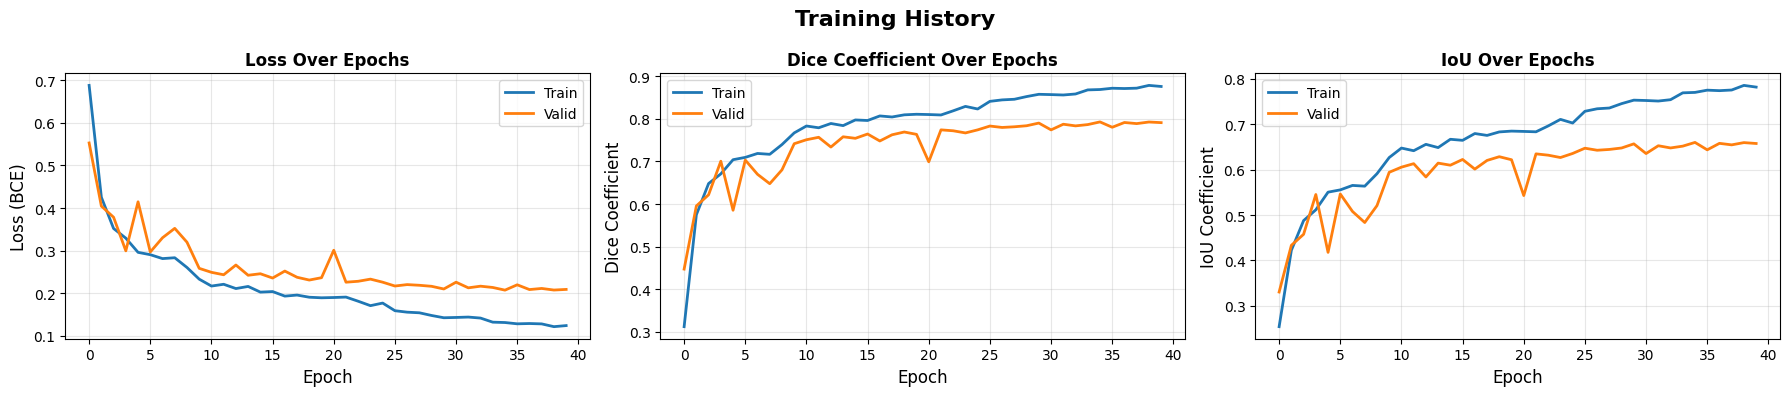


Evaluating on Test Set

📊 Test Results:
  - Loss: 0.2197
  - Dice Coefficient: 0.7803
  - IoU Coefficient: 0.6421

✓ Metrics saved to /content/outputs/metrics.txt


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['valid_loss'], label='Valid', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (BCE)', fontsize=12)
axes[0].set_title('Loss Over Epochs', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Dice Coefficient
axes[1].plot(history['train_dice'], label='Train', linewidth=2)
axes[1].plot(history['valid_dice'], label='Valid', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Dice Coefficient', fontsize=12)
axes[1].set_title('Dice Coefficient Over Epochs', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# IoU
axes[2].plot(history['train_iou'], label='Train', linewidth=2)
axes[2].plot(history['valid_iou'], label='Valid', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('IoU Coefficient', fontsize=12)
axes[2].set_title('IoU Over Epochs', fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
print(f"\n{'='*60}")
print("Evaluating on Test Set")
print(f"{'='*60}")

test_loss, test_dice, test_iou = evaluate(
    model, test_loader, CONFIG['device']
)

print(f"\n📊 Test Results:")
print(f"  - Loss: {test_loss:.4f}")
print(f"  - Dice Coefficient: {test_dice:.4f}")
print(f"  - IoU Coefficient: {test_iou:.4f}")

# Save metrics to file
if IN_COLAB:
    metrics_path = os.path.join(COLAB_OUTPUT_PATH, 'metrics.txt')
    with open(metrics_path, 'w') as f:
        f.write("Brain Tumor Segmentation - U-Net Results\n")
        f.write("="*50 + "\n\n")
        f.write("Final Test Metrics:\n")
        f.write(f"  Loss: {test_loss:.4f}\n")
        f.write(f"  Dice Coefficient: {test_dice:.4f}\n")
        f.write(f"  IoU Coefficient: {test_iou:.4f}\n")
    print(f"\n✓ Metrics saved to {metrics_path}")

## Generate Segmentation Predictions

Generating predictions on test samples...


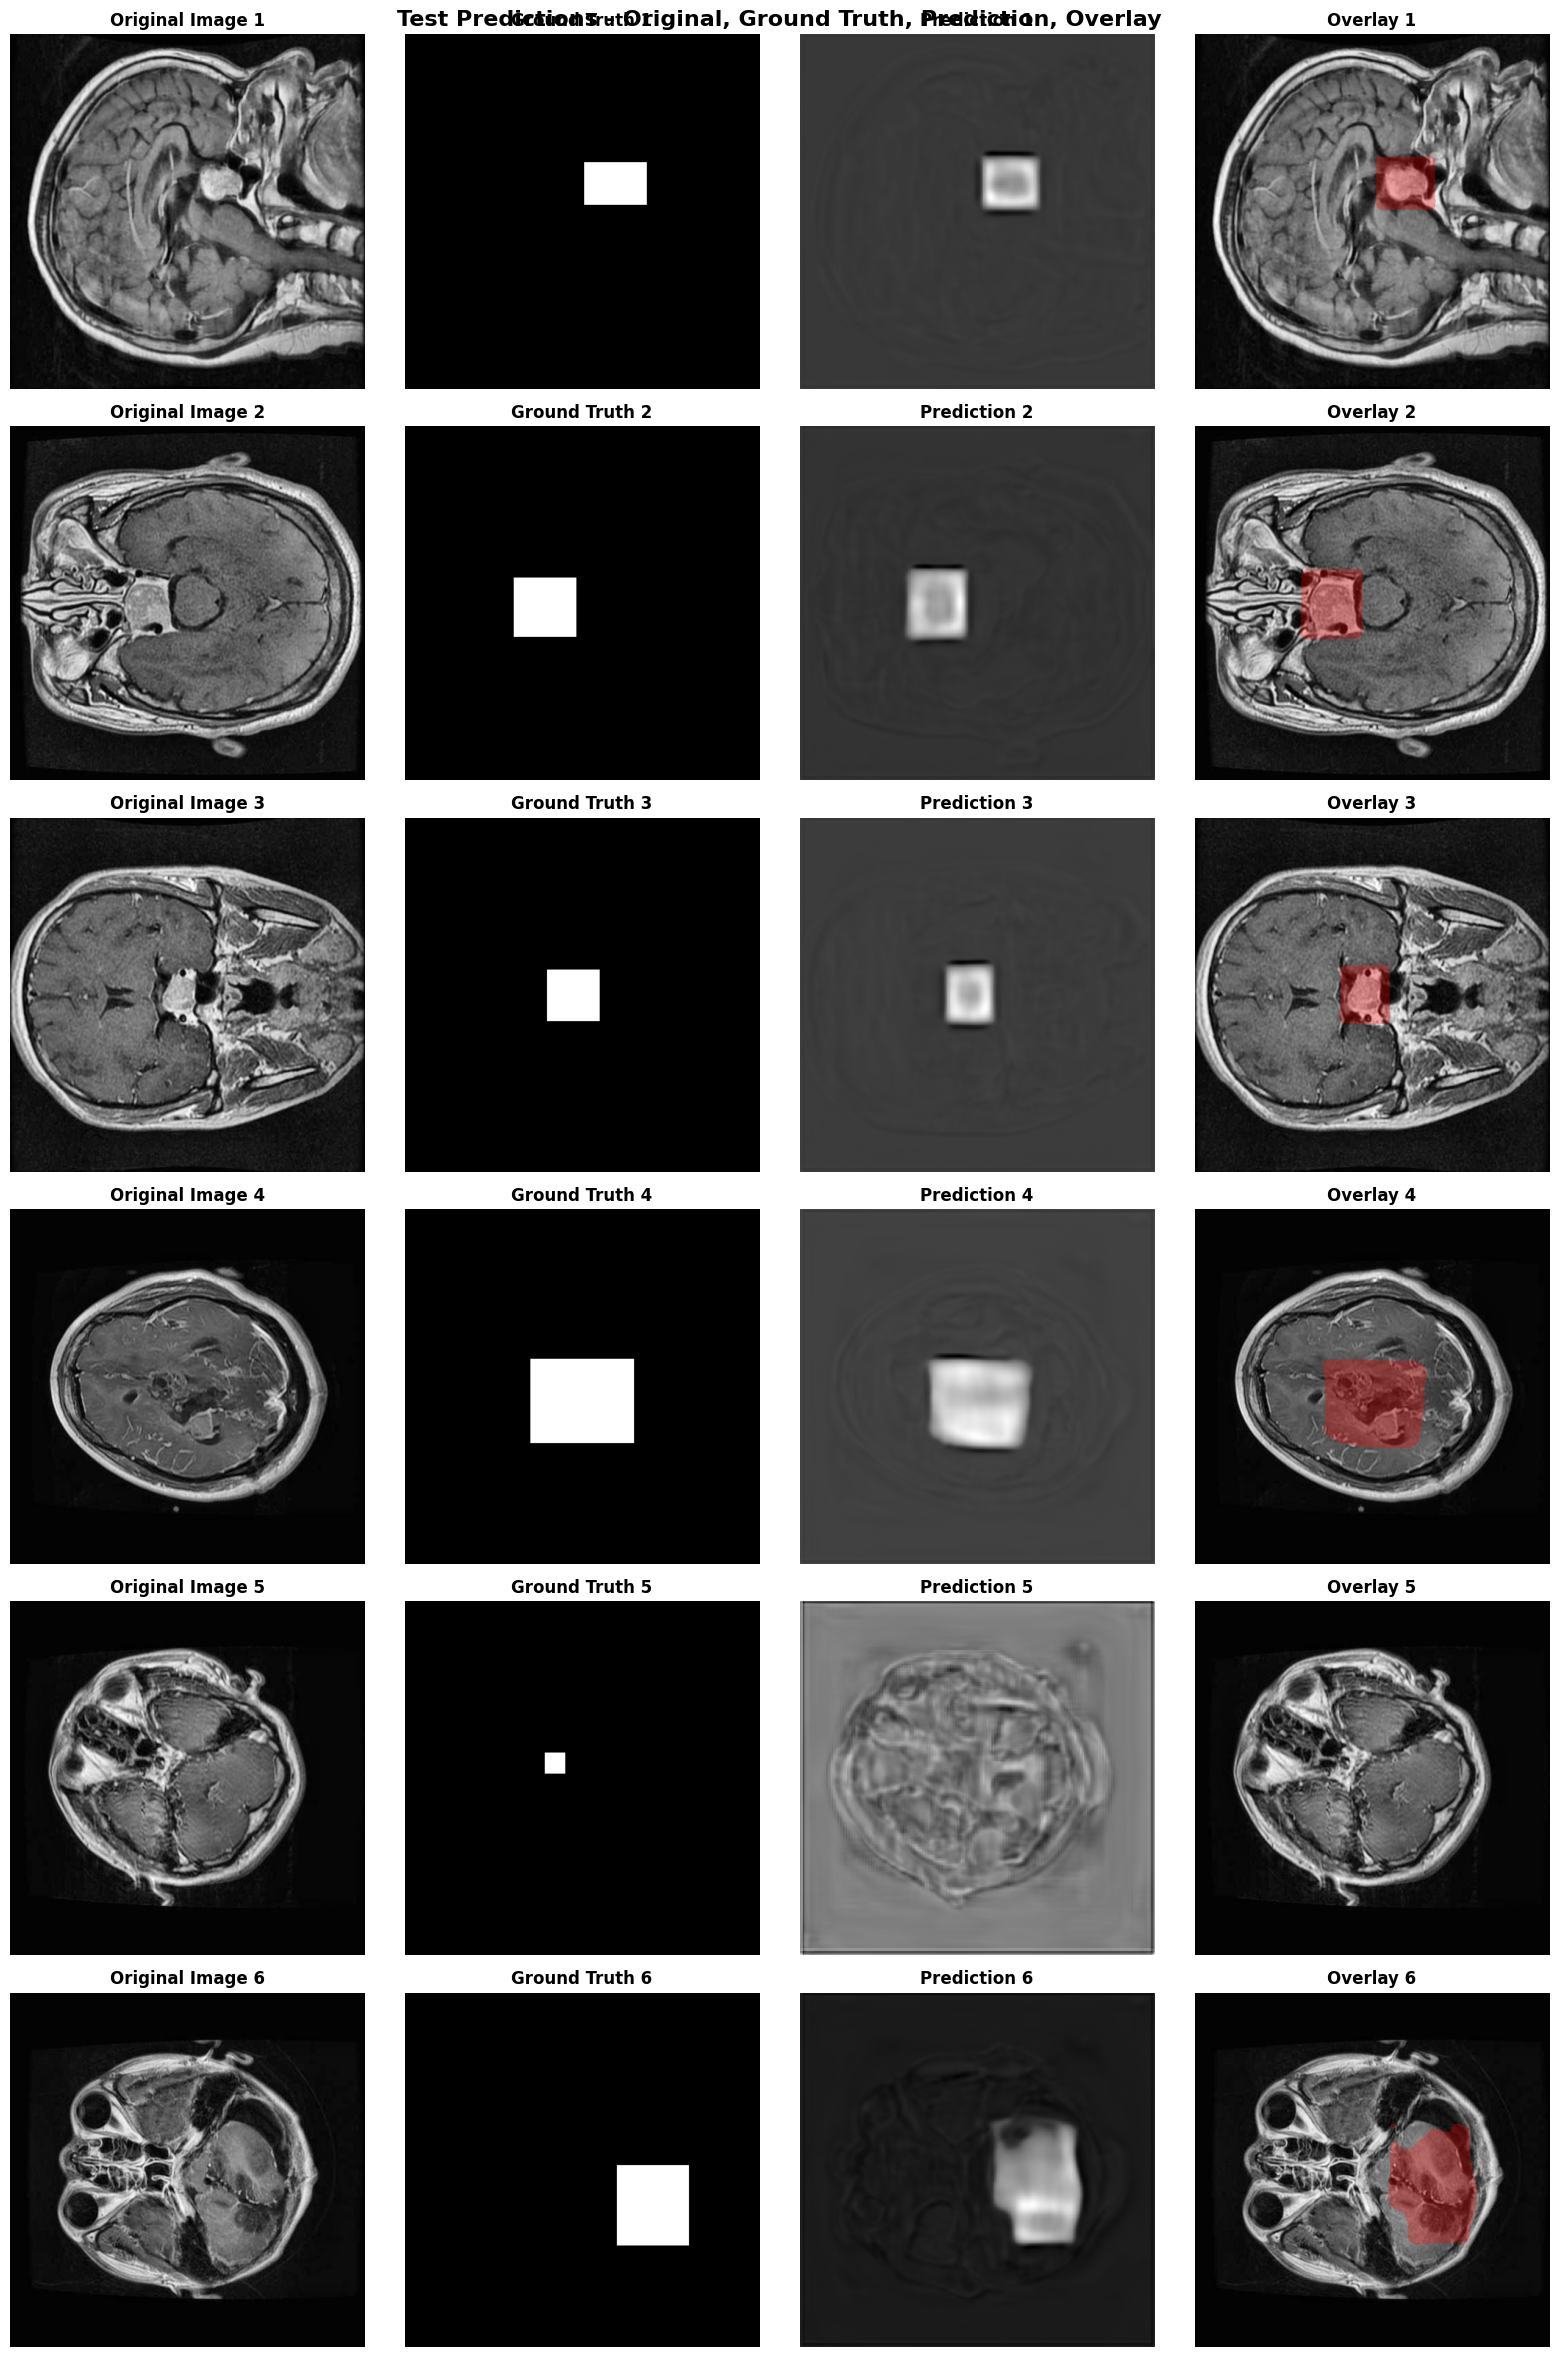

✓ Predictions generated successfully!

Saving Model
✓ Model saved to /content/outputs/best_unet_model.pth
✓ Training history saved to /content/outputs/training_history.txt

✅ TRAINING COMPLETE!

📊 Final Results:
  Device: cuda
  Total Epochs: 40
  Best Validation Loss: 0.2072
  Best Validation Dice: 0.7928
  Best Validation IoU: 0.6597
  Test Loss: 0.2197
  Test Dice: 0.7803
  Test IoU: 0.6421

💾 Saved Files:
  - Model weights: /content/outputs/best_unet_model.pth
  - Training history: /content/outputs/training_history.txt
  - Metrics: /content/outputs/metrics.txt

🎉 Done!


In [14]:
# Generate predictions on test samples
def predict(model, image, device):
    """Generate prediction for a single image"""
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        output = model(image)
        output = output.squeeze().cpu().numpy()
    return output

# Visualize predictions
print("Generating predictions on test samples...")
num_samples = min(6, len(test_data))

fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
fig.suptitle('Test Predictions - Original, Ground Truth, Prediction, Overlay',
             fontsize=16, fontweight='bold')

model.eval()

for idx in range(num_samples):
    # Load image
    img_path = test_data[idx]['image_path']
    image = cv2.imread(img_path)
    if image is not None:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    else:
        image_rgb = np.zeros((test_data[idx]['height'], test_data[idx]['width'], 3), dtype=np.uint8)

    # Get original mask
    original_mask = test_data[idx]['mask']

    # Preprocess for model
    image_resized = cv2.resize(image_rgb, CONFIG['img_size'])
    image_normalized = image_resized.astype(np.float32) / 255.0
    image_tensor = torch.from_numpy(image_normalized).permute(2, 0, 1)

    # Get prediction
    pred_mask = predict(model, image_tensor, CONFIG['device'])
    pred_mask_binary = (pred_mask > 0.5).astype(np.uint8)

    # Resize prediction back to original size
    pred_mask_orig = cv2.resize(pred_mask,
                                (test_data[idx]['width'], test_data[idx]['height']),
                                interpolation=cv2.INTER_LINEAR)

    # Create overlay
    overlay = image_rgb.copy().astype(np.float32)
    overlay[pred_mask_orig > 0.5] = [255, 0, 0]
    overlay = overlay.astype(np.uint8)
    blended = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)

    # Plot
    axes[idx, 0].imshow(image_rgb)
    axes[idx, 0].set_title(f'Original Image {idx+1}', fontweight='bold')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(original_mask, cmap='gray')
    axes[idx, 1].set_title(f'Ground Truth {idx+1}', fontweight='bold')
    axes[idx, 1].axis('off')

    # Resize prediction to visualization size for comparison
    pred_mask_resized = cv2.resize(pred_mask, CONFIG['img_size'])
    axes[idx, 2].imshow(pred_mask_resized, cmap='gray')
    axes[idx, 2].set_title(f'Prediction {idx+1}', fontweight='bold')
    axes[idx, 2].axis('off')

    axes[idx, 3].imshow(blended)
    axes[idx, 3].set_title(f'Overlay {idx+1}', fontweight='bold')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()

print("✓ Predictions generated successfully!")

# Save model
print("\n" + "="*60)
print("Saving Model")
print("="*60)

if IN_COLAB:
    model_path = os.path.join(COLAB_OUTPUT_PATH, 'best_unet_model.pth')
else:
    model_path = 'best_unet_model.pth'

torch.save(model.state_dict(), model_path)
print(f"✓ Model saved to {model_path}")

# Save training history
if IN_COLAB:
    history_path = os.path.join(COLAB_OUTPUT_PATH, 'training_history.txt')
else:
    history_path = 'training_history.txt'

with open(history_path, 'w') as f:
    f.write("Brain Tumor Segmentation U-Net - Training History\n")
    f.write("="*60 + "\n\n")
    f.write("Epoch-by-Epoch Results:\n")
    f.write("-"*60 + "\n")
    f.write(f"{'Epoch':<8}{'Train Loss':<12}{'Valid Loss':<12}{'Train Dice':<12}{'Valid Dice':<12}{'Train IoU':<12}{'Valid IoU':<12}\n")
    f.write("-"*60 + "\n")

    for epoch in range(len(history['train_loss'])):
        f.write(f"{epoch+1:<8}{history['train_loss'][epoch]:<12.4f}{history['valid_loss'][epoch]:<12.4f}")
        f.write(f"{history['train_dice'][epoch]:<12.4f}{history['valid_dice'][epoch]:<12.4f}")
        f.write(f"{history['train_iou'][epoch]:<12.4f}{history['valid_iou'][epoch]:<12.4f}\n")

print(f"✓ Training history saved to {history_path}")

# Final summary
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"\n📊 Final Results:")
print(f"  Device: {CONFIG['device']}")
print(f"  Total Epochs: {len(history['train_loss'])}")
print(f"  Best Validation Loss: {min(history['valid_loss']):.4f}")
print(f"  Best Validation Dice: {max(history['valid_dice']):.4f}")
print(f"  Best Validation IoU: {max(history['valid_iou']):.4f}")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Dice: {test_dice:.4f}")
print(f"  Test IoU: {test_iou:.4f}")
print(f"\n💾 Saved Files:")
print(f"  - Model weights: {model_path}")
print(f"  - Training history: {history_path}")
if IN_COLAB:
    print(f"  - Metrics: {os.path.join(COLAB_OUTPUT_PATH, 'metrics.txt')}")
print(f"\n🎉 Done!")